<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [1]:
versuchsnummer = "252"
versuchsname = "Aktivierung_mit_hermischen_Neutronen" 
aufgabe = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [2]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import const
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

c:\Folders\Uni-Heidelberg\Praktika\PAP2\IDE_PAP2\PAP-2\Versuche\252\Python\Papulator.py:107: SyntaxWarning: invalid escape sequence '\p'
  '''


<hr>
<hr>

# Auswertung der Aufgaben

<hr>

## Aufgabe 1) Silber

In [3]:
# Untergrundmessung
unterg = np.loadtxt('./data/untergrundAJ.txt', usecols = [1])

print(np.mean(unterg)*12)
print(np.std(unterg) / np.sqrt(len(unterg)))
print('-'*15)

mean_unterg = 4 * np.mean(unterg)
sig_mean_unterg = np.std(4 * unterg) / np.sqrt(len(unterg))

print(fr'Der Mittelwert der Untergrundmessung liegt bei: {pap.round_sig_digs(sig_mean_unterg,mean_unterg)[2]}')

40.25
0.27400321770042263
---------------
Der Mittelwert der Untergrundmessung liegt bei: 13.4 \pm 1.1


In [4]:
# Definition der Regressionsfunktion
y0 = mean_unterg
def expo(x, A1, l1, A2, l2):
    return A1 * exp(-l1 * x) + A2 * exp(-l2 * x) + y0

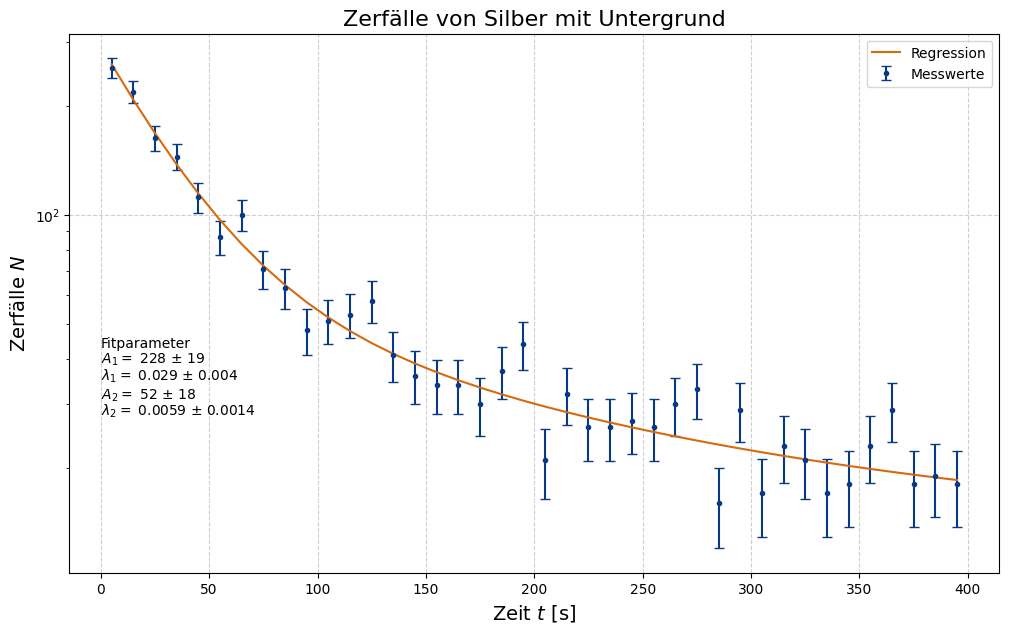

In [5]:
aufgabe = '1a'

# Import der Messdaten
n1 = np.loadtxt('data/SilberAJ1.txt', usecols = [1])
n2 = np.loadtxt('data/SilberAJ2.txt', usecols = [1])
n3 = np.loadtxt('data/SilberAJ3.txt', usecols = [1])
n4 = np.loadtxt('data/SilberAJ4.txt', usecols = [1])

N = n1 + n2 + n3 + n4
sig_N = np.sqrt(N)
t = np.arange(5, 405, 10)

# Regression
popt, pcov = curve_fit(expo, t, N, sigma = sig_N, p0 = [250, 0.2, 50, 0.001])

# Fitparameter
A_1 = popt[0]
sig_A_1 = pcov[0,0]
err_A_1 = sqrt(sig_A_1)


l_1 = popt[1]
sig_l_1 = pcov[1,1]
err_l_1 = sqrt(sig_l_1)

A_2 = popt[2]
sig_A_2 = pcov[2,2]
err_A_2 = sqrt(sig_A_2)

l_2 = popt[3]
sig_l_2 = pcov[3,3]
err_l_2 = sqrt(sig_l_2)

# Plot
plt.figure(figsize = (12,7))

# Messungen
plt.errorbar(
    t, 
    N, 
    yerr = sig_N, 
    fmt = '.', 
    capsize = 3.5, 
    label = 'Messwerte',
    color = c.BLUE
    )

plt.xlabel('Zeit $t$ [s]', size = 14)
plt.ylabel('Zerfälle $N$', size = 14)
plt.title('Zerfälle von Silber mit Untergrund', size = 16)
plt.yscale('log')

# Fit
plt.plot(
    t, 
    expo(t, *popt), 
    label = 'Regression',
    color = c.ORANGE
    )



plt.text(0, 4.3e1, 'Fitparameter')
plt.text(0, 3.9e1, f'$A_1 = $ {pap.round_sig_digs(err_A_1, A_1)[3]}')
plt.text(0, 3.5e1, f'$\\lambda_1 = $ {pap.round_sig_digs(err_l_1, l_1)[3]}')
plt.text(0, 3.1e1, f'$A_2 = $ {pap.round_sig_digs(err_A_2, A_2)[3]}')
plt.text(0, 2.8e1, f'$\\lambda_2 = $ {pap.round_sig_digs(err_l_2, l_2)[3]}')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(loc = 'best')
plt.savefig(f'{plt_save_folder}Regression_der_Messdaten_{aufgabe}.pdf', dpi=300)
plt.show()

In [6]:
# Güte des Fits
chi2_= np.sum((expo(t, *popt) - N) ** 2 / sig_N ** 2)
dof = len(N) - 4 #dof:degrees of freedom, Freiheitsgrad
chi2_red = chi2_/dof

print("chi2 =", round(chi2_,2))
print("chi2_red =", round(chi2_red,2))

prob = np.round(1 - chi2.cdf(chi2_,dof),2) * 100
print("Wahrscheinlichkeit =", prob, "%")

chi2 = 35.07
chi2_red = 0.97
Wahrscheinlichkeit = 51.0 %


<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
C:\Users\finnz\AppData\Local\Temp\ipykernel_18484\2777945645.py:19: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Zerfälle von Silber mit Untergrund $\pm$ Fehler', size = 16)


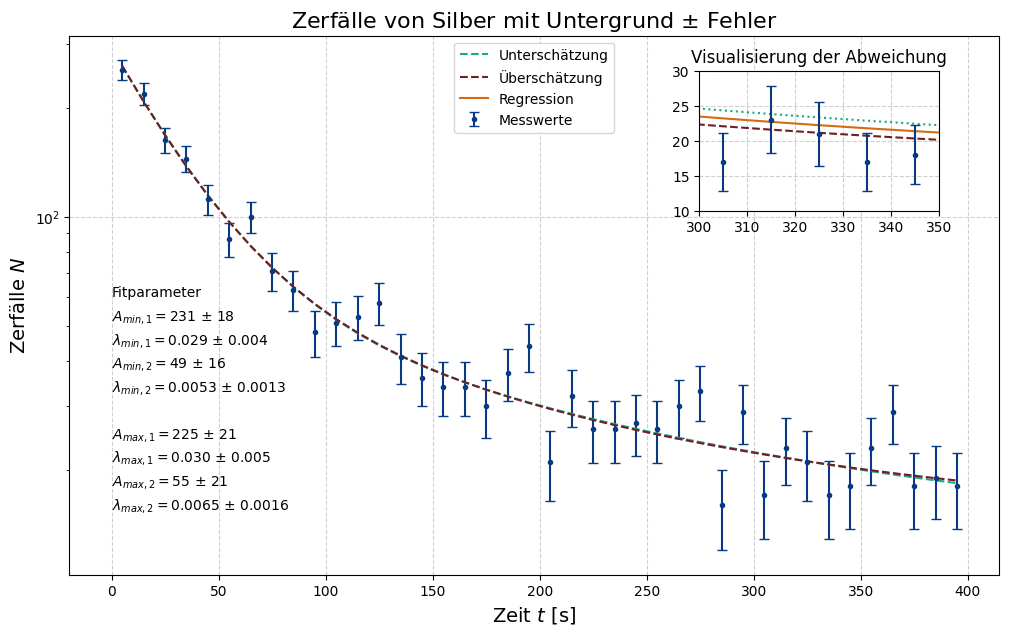

In [7]:
aufgabe = '1b'
# Fit unter Berücksichtigung des Untergrund-Fehlers
# Plot
plt.figure(figsize = (12,7))

# Messungen
plt.errorbar(
    t, 
    N, 
    yerr = sig_N, 
    fmt = '.', 
    capsize = 3.5, 
    label = 'Messwerte',
    color = c.BLUE
    )

plt.xlabel('Zeit $t$ [s]', size = 14)
plt.ylabel('Zerfälle $N$', size = 14)
plt.title('Zerfälle von Silber mit Untergrund $\pm$ Fehler', size = 16)
plt.yscale('log')

# Fit
y0 = mean_unterg - sig_mean_unterg # Unterschätzt
popt_min, pcov_min = curve_fit(expo, t, N, sigma = sig_N,
p0 = [250, 0.2, 50, 0.01])

# Fitparemeter
A_min_1 = popt_min[0]
sig_A_min_1 = pcov_min[0,0]
err_A_min_1 = sqrt(sig_A_min_1)

l_min_1 = popt_min[1]
sig_l_min_1 = pcov_min[1,1]
err_l_min_1 = sqrt(sig_l_min_1)

A_min_2 = popt_min[2]
sig_A_min_2 = pcov_min[2,2]
err_A_min_2 = sqrt(sig_A_min_2)

l_min_2 = popt_min[3]
sig_l_min_2 = pcov_min[3,3]
err_l_min_2 = sqrt(sig_l_min_2)

plt.plot(
    t, 
    expo(t, *popt_min), 
    label = 'Unterschätzung', 
    ls = '--',
    color = c.LIGHT_GREEN
    )

# Fitparameter als Text im Plot
text_pos_upper = 4.1
plt.text(0, exp(text_pos_upper), 
         'Fitparameter')

plt.text(0, exp(text_pos_upper - 0.15), 
         '$A_{min,1} = $' + str(pap.round_sig_digs(err_A_min_1, A_min_1)[3]))

plt.text(0, exp(text_pos_upper - 0.3), 
         '$\\lambda_{min,1} = $' + str(pap.round_sig_digs(err_l_min_1, l_min_1)[3]))

plt.text(0, exp(text_pos_upper - 0.45), 
         '$A_{min,2} = $' + str(pap.round_sig_digs(err_A_min_2, A_min_2)[3]))

plt.text(0, exp(text_pos_upper - 0.6), 
         '$\\lambda_{min,2} = $' + str(pap.round_sig_digs(err_l_min_2, l_min_2)[3]))

y0 = mean_unterg + sig_mean_unterg # Überschätzt
popt_max, pcov_max = curve_fit(expo, t, N, sigma = sig_N, p0 = [250, 0.2, 50, 0.01])

# Fitparameter
A_max_1 = popt_max[0]
sig_A_max_1 = pcov_max[0,0]
err_A_max_1 = sqrt(sig_A_max_1)

l_max_1 = popt_max[1]
sig_l_max_1 = pcov_max[1,1]
err_l_max_1 = sqrt(sig_l_max_1)

A_max_2 = popt_max[2]
sig_A_max_2 = pcov_max[2,2]
err_A_max_2 = sqrt(sig_A_max_2)

l_max_2 = popt_max[3]
sig_l_max_2 = pcov_max[3,3]
err_l_max_2 = sqrt(sig_l_max_2)

plt.plot(
    t, 
    expo(t, *popt_max), 
    label = 'Überschätzung', 
    ls = '--',
    color = c.WINE_RED
    )

plt.plot(
    # t, 
    # expo(t, *popt), 
    0, 
    0,
    label = 'Regression', 
    color = c.ORANGE,
    )

text_pos_upper_2 = 3.2
plt.text(0, exp(text_pos_upper_2), 
         '$A_{max,1} = $' + str(pap.round_sig_digs(err_A_max_1, A_max_1)[3]))

plt.text(0, exp(text_pos_upper_2 - 0.15), 
         '$\\lambda_{max,1} = $' + str(pap.round_sig_digs(err_l_max_1, l_max_1)[3]))

plt.text(0, exp(text_pos_upper_2 - 0.3), 
         '$A_{max,2} = $' + str(pap.round_sig_digs(err_A_max_2, A_max_2)[3]))

plt.text(0, exp(text_pos_upper_2 - 0.45), 
         '$\\lambda_{max,2} = $' + str(pap.round_sig_digs(err_l_max_2, l_max_2)[3]))

plt.grid(True, ls='--', alpha=0.6)

plt.legend(loc = 'upper center')

# Kleines Fenster oben rechts
a = plt.axes([.65, .63, .2, .2], facecolor = 'white')

plt.plot(
    t, 
    expo(t, *popt_min), 
    color = c.LIGHT_GREEN, 
    ls = 'dotted'
    )

plt.plot(
    t, 
    expo(t, *popt_max),
    color = c.WINE_RED, 
    ls = '--'
    )

plt.plot(
    t, 
    expo(t, *popt), 
    color = c.ORANGE,
    )

plt.errorbar(
    t, 
    N, 
    yerr = sig_N, 
    fmt = '.', 
    capsize = 3.5,
    color = c.BLUE
    )

plt.xlim(300, 350)
plt.ylim(10, 30)
plt.title('Visualisierung der Abweichung')

plt.grid(True, ls='--', alpha=0.6)

plt.savefig(f'{plt_save_folder}Regression_der_Messdaten_{aufgabe}.pdf', dpi=300)

plt.show()

In [8]:
# Differenz der Zerfallskonstanten:
sig_min_l_1 = np.abs(l_1 - l_min_1)
sig_max_l_1 = np.abs(l_1 - l_max_1)
sig_min_l_2 = np.abs(l_2 - l_min_2)
sig_max_l_2 = np.abs(l_2 - l_max_2)
err_l_1 = sqrt(((sig_min_l_1 + sig_max_l_1) / 2) ** 2 + sig_l_1 ** 2 )
err_l_2 = sqrt(((sig_min_l_2 + sig_max_l_2) / 2) ** 2 + sig_l_2 ** 2 )

print(fr'Zerfallskonstante l_1 = ({pap.round_sig_digs(err_l_1, l_1)[2]}) 1/s')
print(fr'Zerfallskonstante l_2 = ({pap.round_sig_digs(err_l_2, l_2)[2]}) 1/s')

# Hlabwertszeiten
T_halb_1 = log(2) / l_1
err_T_halb_1 = log(2) * err_l_1 / (l_1**2)

T_halb_2 = log(2) / l_2
err_T_halb_2 = log(2) * err_l_2 / (l_2**2)

print(fr'Halbwertszeit T_Halb_1 = ({pap.round_sig_digs(err_T_halb_1, T_halb_1)[2]}) s')
print(fr'Halbwertszeit T_Halb_2 = ({pap.round_sig_digs(err_T_halb_2, T_halb_2)[2]}) s')

# Lebensdauern
tau_1 = 1 / l_1
err_tau_1 = 1 * err_l_1 / (l_1**2)

tau_2 = 1 / l_2
err_tau_2 = 1 * err_l_2 / (l_2**2)

print(fr'Lebensdauer tau_1 = ({pap.round_sig_digs(err_tau_1, tau_1)[2]}) s')
print(fr'Lebensdauer tau_2 = ({pap.round_sig_digs(err_tau_2, tau_2)[2]}) s')

Zerfallskonstante l_1 = (0.0291 \pm 0.0005) 1/s
Zerfallskonstante l_2 = (0.0059 \pm 0.0006) 1/s
Halbwertszeit T_Halb_1 = (23.8 \pm 0.4) s
Halbwertszeit T_Halb_2 = (118 \pm 12) s
Lebensdauer tau_1 = (34.3 \pm 0.6) s
Lebensdauer tau_2 = (171 \pm 18) s


In [9]:
# Standardabweichung
print(fr'Standardabweichung für ^110 Ag: {pap.std_abw(T_halb_1, 24.6, err_T_halb_1)}')
print(fr'Standardabweichung für ^108 Ag: {pap.std_abw(T_halb_2, 144.6, err_T_halb_2)}')

# Relativer Fehler
print(fr'Relativer Fehler für ^110 Ag: {err_T_halb_1/T_halb_1:.2g}')
print(fr'Relativer Fehler für ^108 Ag: {err_T_halb_2/T_halb_2:.2g}')


Standardabweichung für ^110 Ag: 1.96
Standardabweichung für ^108 Ag: 2.16
Relativer Fehler für ^110 Ag: 0.017
Relativer Fehler für ^108 Ag: 0.1


<hr>

## Aufgabe 2) Indium

In [10]:
# Untergrundmessung
unterg_In = np.loadtxt('data/untergrundAJ.txt', usecols = [1])

print(np.mean(unterg_In)*12)
print(np.std(unterg_In) / np.sqrt(len(unterg_In)))
print('-'*15)
mean_unterg_In = 12 * np.mean(unterg_In)
sig_mean_unterg_In = np.std(12 * unterg_In) / np.sqrt(len(unterg_In))

print('Der Mittelwert des Untergrundes bei der Indium Messung beträgt:')
print(pap.round_sig_digs(sig_mean_unterg_In, mean_unterg_In)[2])


40.25
0.27400321770042263
---------------
Der Mittelwert des Untergrundes bei der Indium Messung beträgt:
40 \pm 3


In [11]:
# Neue Regressionsfunktion
y0 = mean_unterg_In
def expo_In(x, A1, l1):
    return A1 * exp(-l1 * x) + y0

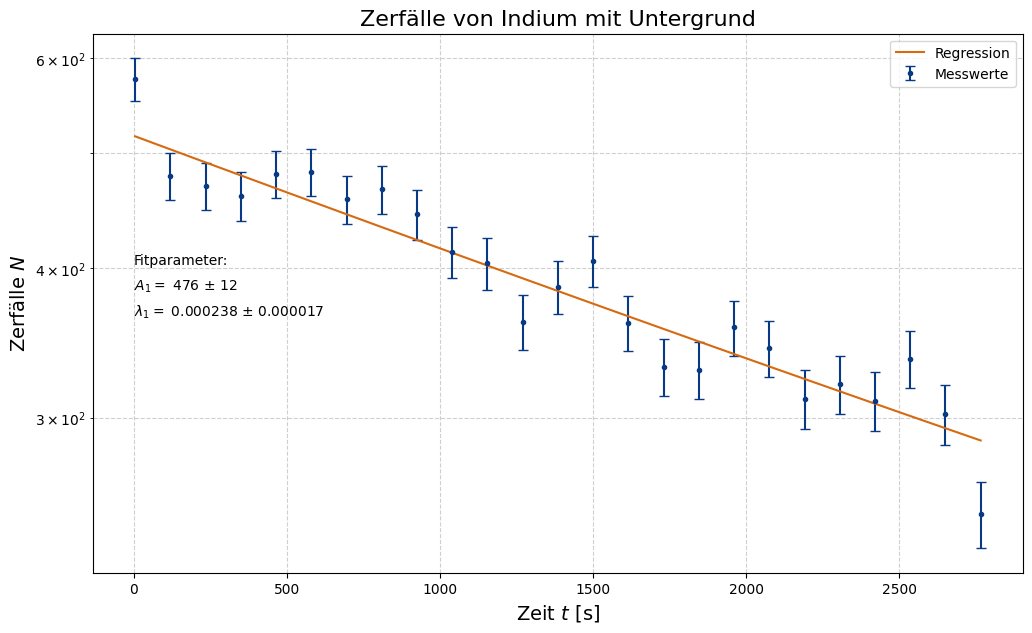

In [12]:
aufgabe = '2a'
# Bestimmung der Zerfallskonstante
N_In = np.loadtxt('data/IndiumAJ.txt', usecols = [1])
sig_N_In = np.sqrt(N_In)
t_In = np.arange(5, 2800, 115)

# Fit
popt_In, pcov_In = curve_fit(expo_In, t_In[1:], N_In[1:], sigma = sig_N_In[1:],
p0 = [600, 0.002])

# Fitparameter
A_In = popt_In[0]
sig_A_In = pcov_In[0,0]
err_A_In = sqrt(sig_A_In)

l_In = popt_In[1]
sig_l_In = pcov_In[1,1]
err_l_In = sqrt(sig_l_In)

# Plot
plt.figure(figsize = (12,7))

# Messungen
plt.errorbar(
    t_In, 
    N_In, 
    yerr = sig_N_In, 
    fmt = '.', 
    capsize = 3.5,
    label = 'Messwerte',
    color = c.BLUE
    )

plt.xlabel('Zeit $t$ [s]', size = 14)
plt.ylabel('Zerfälle $N$', size = 14)
plt.title('Zerfälle von Indium mit Untergrund', size = 16)
plt.yscale('log')

# Regression
plt.plot(
    t_In, 
    expo_In(t_In, *popt_In), 
    label = 'Regression',
    color = c.ORANGE
    )

# Text mit den Fitparametern
text_top_pos_in = 6
plt.text(0, exp(text_top_pos_in), 'Fitparameter:')

plt.text(0, exp(text_top_pos_in - 0.05),
         f'$A_1 = $ {pap.round_sig_digs(err_A_In, A_In)[3]}'
         )

plt.text(0, exp(text_top_pos_in - 0.1),
         f'$\\lambda_1 = $ {pap.round_sig_digs(err_l_In, l_In)[3]}'
         )


plt.legend(loc = 'best')
plt.grid(True, 'both', 'both', ls='--', alpha=0.6)

plt.savefig(f'{plt_save_folder}Regression_der_Messdaten_{aufgabe}.pdf', dpi=300)

plt.show()

In [13]:
# Güte des Fits
chi2_= np.sum((expo_In(t_In, *popt_In) - N_In) ** 2 / sig_N_In ** 2)
dof = len(N_In) - 2 #dof:degrees of freedom, Freiheitsgrad
chi2_red = chi2_/dof

print("chi2 =", round(chi2_, 2))
print("chi2_red =", round(chi2_red, 2))

prob = np.round(1 - chi2.cdf(chi2_,dof),2) * 100
print("Wahrscheinlichkeit =", prob, "%")

chi2 = 34.76
chi2_red = 1.51
Wahrscheinlichkeit = 5.0 %


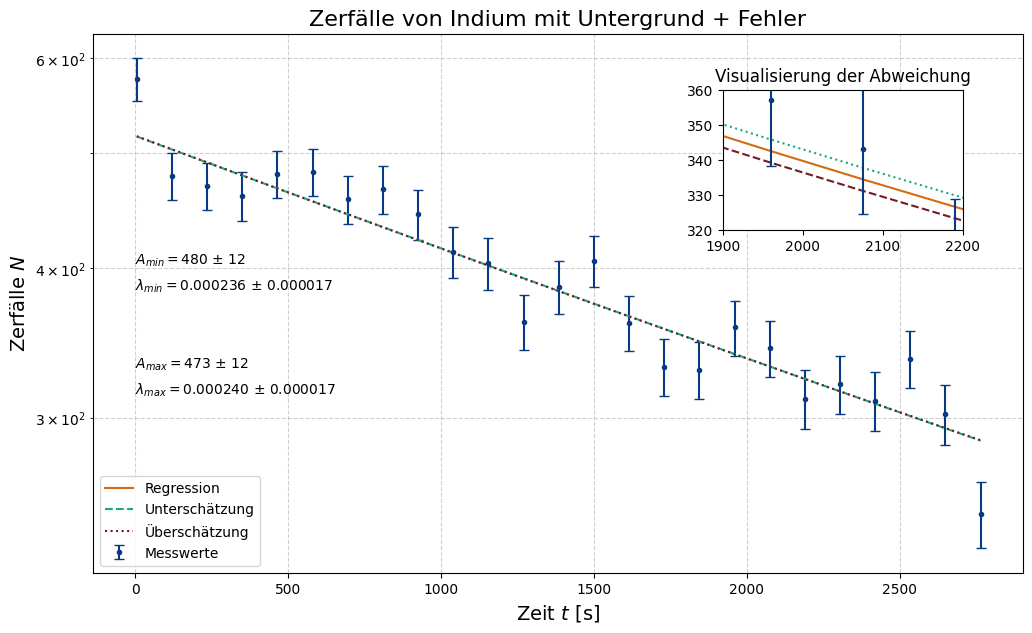

In [14]:
aufgabe = '2b'
# Fit unter Berücksichtigung des Untergrund-Fehlers
# Fit unterschätzt
y0 = mean_unterg_In - sig_mean_unterg_In
popt_min, pcov_min = curve_fit(expo_In, t_In[1:], N_In[1:], sigma = sig_N_In[1:],
p0 = [600, 0.002])

# Fitparemeter
A_min_In = popt_min[0]
sig_A_min_In = pcov_min[0,0]
err_A_min_In =sqrt(sig_A_min_In)

l_min_In = popt_min[1]
sig_l_min_In = pcov_min[1,1]
err_l_min_In =sqrt(sig_l_min_In)

# Plot
plt.figure(figsize = (12,7))

# Messungen
plt.errorbar(
    t_In,
    N_In, 
    yerr = sig_N_In, 
    fmt = '.', 
    capsize = 3.5,
    label = 'Messwerte',
    color = c.BLUE
    )

plt.xlabel('Zeit $t$ [s]', size = 14)
plt.ylabel('Zerfälle $N$', size = 14)
plt.title('Zerfälle von Indium mit Untergrund + Fehler', size = 16)
plt.yscale('log')

plt.plot(
    # t_In, 
    # expo_In(t_In, *popt_In), 
    0,
    0,
    color = c.ORANGE,
    label='Regression'
    )

# Plot min
plt.plot(
    t_In, 
    expo_In(t_In, *popt_min), 
    label = 'Unterschätzung', 
    ls = '--',
    color = c.LIGHT_GREEN
    )

txt_pos = 6
plt.text(0, exp(txt_pos), '$A_{min} = $' + str(pap.round_sig_digs(err_A_min_In, A_min_In)[3]))
plt.text(0, exp(txt_pos - 0.05), '$\\lambda_{min} = $' + str(pap.round_sig_digs(err_l_min_In, l_min_In)[3]))

# Fit überschätzt
y0 = mean_unterg_In + sig_mean_unterg_In
popt_max, pcov_max = curve_fit(expo_In, t_In[1:], N_In[1:], sigma = sig_N_In[1:],
p0 = [600, 0.002])

# Fitparameter
A_max_In = popt_max[0]
sig_A_max_In = pcov_max[0,0]
err_A_max_In = sqrt(sig_A_max_In)

l_max_In = popt_max[1]
sig_l_max_In = pcov_max[1,1]
err_l_max_In = sqrt(sig_l_max_In)

# Plot max
plt.plot(t_In, expo_In(t_In, *popt_max), label = 'Überschätzung', ls = 'dotted',
color = c.WINE_RED)

txt_pos_2 = 5.8
plt.text(0, exp(txt_pos_2), '$A_{max} = $' + str(pap.round_sig_digs(err_A_max_In, A_max_In)[3]))
plt.text(0, exp(txt_pos_2 - 0.05), '$\\lambda_{max} = $' + str(pap.round_sig_digs(err_l_max_In, l_max_In)[3]))
plt.legend(loc = 'lower left')
plt.grid(True, 'both', 'both', ls='--', alpha=0.6)

# Kleines Rechteck oben rechts
a = plt.axes([.65, .6, .2, .2], facecolor = 'white')

plt.plot(
    t_In, 
    expo_In(t_In, *popt_min), 
    color = c.LIGHT_GREEN, 
    ls = 'dotted'
    )

plt.plot(
    t_In, 
    expo_In(t_In, *popt_max), 
    color = c.WINE_RED, 
    ls = '--'
    )

plt.plot(
    t_In, 
    expo_In(t_In, *popt_In), 
    color = c.ORANGE
    )

plt.errorbar(
    t_In, 
    N_In, 
    yerr = sig_N_In, 
    fmt = '.', 
    capsize = 3.5,
    color = c.BLUE
    )

plt.xlim(1900, 2200)
plt.ylim(320, 360)
plt.title('Visualisierung der Abweichung')

plt.savefig(f'{plt_save_folder}Regression_der_Messdaten_{aufgabe}.pdf', dpi=300)

plt.show()

In [15]:
# Differenz der Zerfallskonstanten:
sig_min_l_In = np.abs(l_In - l_min_In)
sig_max_l_In = np.abs(l_In - l_max_In)
err_l_In = sqrt( ((sig_min_l_In + sig_max_l_In) / 2) ** 2 + sig_l_In ** 2 )

pot = 1e-4
print(fr'Zerfallskonstante l_In = ({pap.round_sig_digs(err_l_In/pot, l_In/pot)[2]}) * {pot:.1g} 1/s')

T_halb_In = log(2) / l_In
err_T_halb_In = log(2) * err_l_In / (l_In ** 2)
print(fr'Halbwertszeit T_halb = ({pap.round_sig_digs(err_T_halb_In, T_halb_In)[2]})s')

tau_In = 1/l_In
err_tau_In = 1 * err_l_In / (l_In ** 2)
print(fr'Lebensdauer tau = ({pap.round_sig_digs(err_tau_In, tau_In)[2]})s')

Zerfallskonstante l_In = (2.378 \pm 0.023) * 0.0001 1/s
Halbwertszeit T_halb = (2910 \pm 30)s
Lebensdauer tau = (4210 \pm 40)s


In [ ]:
# Standardabweichung
print(fr'Standardabweichung für Indum: {pap.std_abw(T_halb_In, 3240, err_T_halb_In, 1)}')

# Relativer Fehler
print(fr'Relativer Fehler für Indium: {err_T_halb_In/T_halb_In:.2g}')

325.30044941691403
Standardabweichung für Indum: 11.7
Relativer Fehler für Indium: 0.0095
